In [58]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import mahalanobis
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.impute import KNNImputer
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('C:/Users/Admin/Downloads/csv_file_transformed.csv')
df.head()

,month,town,resale_price,storey_range,flat_type,flat_model,lease_commence_date,remaining_lease_years,remaining_lease_months,floor_area_sqm,...,y,latitude,longitude,closest_mrt_station,distance_to_mrt_meters,transport_type,line_color,distance_to_cbd,closest_pri_school,distance_to_pri_school_meters
0,2017-01-01,ANG MO KIO,232000.0,10 TO 12,2 ROOM,Improved,1979-05-01,61,4,44.0,...,38229.067463,1.362005,103.853880,Ang Mo Kio,999.941618,MRT,Red,8615.656983,TOWNSVILLE PRIMARY SCHOOL,218.125254
1,2017-01-01,ANG MO KIO,250000.0,01 TO 03,3 ROOM,New Generation,1978-08-01,60,7,67.0,...,39220.009892,1.370966,103.838202,Ang Mo Kio,1268.958246,MRT,Red,9715.131951,ANG MO KIO PRIMARY SCHOOL,241.572335
2,2017-01-01,ANG MO KIO,262000.0,01 TO 03,3 ROOM,New Generation,1980-06-01,62,5,67.0,...,40297.283149,1.380709,103.835368,Yio Chu Kang,1072.295164,MRT,Red,10828.819556,ANDERSON PRIMARY SCHOOL,777.155378
3,2017-01-01,ANG MO KIO,265000.0,04 TO 06,3 ROOM,New Generation,1980-02-01,62,1,68.0,...,38693.098657,1.366201,103.857201,Ang Mo Kio,945.371842,MRT,Red,9097.929095,TECK GHEE PRIMARY SCHOOL,698.165530
4,2017-01-01,ANG MO KIO,265000.0,01 TO 03,3 ROOM,New Generation,1980-06-01,62,5,67.0,...,40334.052030,1.381041,103.835132,Yio Chu Kang,1095.197729,MRT,Red,10869.453109,ANDERSON PRIMARY SCHOOL,782.553222


In [3]:
df.shape

(212701, 25)

In [4]:
df.isnull().sum()

month                            0
town                             0
resale_price                     0
storey_range                     0
flat_type                        0
flat_model                       0
lease_commence_date              0
remaining_lease_years            0
remaining_lease_months           0
floor_area_sqm                   0
floor_area_sqft                  0
price_per_sqft                   0
planning_area_ura                0
region_ura                       0
x                                0
y                                0
latitude                         0
longitude                        0
closest_mrt_station              0
distance_to_mrt_meters           0
transport_type                   0
line_color                       0
distance_to_cbd                  0
closest_pri_school               0
distance_to_pri_school_meters    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(304)

In [6]:
df = df.drop_duplicates()

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

month                             object
town                              object
resale_price                     float64
storey_range                      object
flat_type                         object
flat_model                        object
lease_commence_date               object
remaining_lease_years              int64
remaining_lease_months             int64
floor_area_sqm                   float64
floor_area_sqft                  float64
price_per_sqft                   float64
planning_area_ura                 object
region_ura                        object
x                                float64
y                                float64
latitude                         float64
longitude                        float64
closest_mrt_station               object
distance_to_mrt_meters           float64
transport_type                    object
line_color                        object
distance_to_cbd                  float64
closest_pri_school                object
distance_to_pri_

In [9]:
df.drop(labels=['month', 'town', 'x', 'y', 'price_per_sqft', 'lease_commence_date', 'floor_area_sqft'], axis=1, inplace=True)

In [10]:
df['total_lease_remaining_years'] = df['remaining_lease_years'] + df['remaining_lease_months'] / 12

In [11]:
df.drop('remaining_lease_years', axis=1, inplace=True)

In [12]:
df = df.reset_index()
df.head()

,index,resale_price,storey_range,flat_type,flat_model,remaining_lease_months,floor_area_sqm,planning_area_ura,region_ura,latitude,longitude,closest_mrt_station,distance_to_mrt_meters,transport_type,line_color,distance_to_cbd,closest_pri_school,distance_to_pri_school_meters,total_lease_remaining_years
0,0,232000.0,10 TO 12,2 ROOM,Improved,4,44.0,ANG MO KIO,NORTH-EAST REGION,1.362005,103.853880,Ang Mo Kio,999.941618,MRT,Red,8615.656983,TOWNSVILLE PRIMARY SCHOOL,218.125254,61.333333
1,1,250000.0,01 TO 03,3 ROOM,New Generation,7,67.0,ANG MO KIO,NORTH-EAST REGION,1.370966,103.838202,Ang Mo Kio,1268.958246,MRT,Red,9715.131951,ANG MO KIO PRIMARY SCHOOL,241.572335,60.583333
2,2,262000.0,01 TO 03,3 ROOM,New Generation,5,67.0,ANG MO KIO,NORTH-EAST REGION,1.380709,103.835368,Yio Chu Kang,1072.295164,MRT,Red,10828.819556,ANDERSON PRIMARY SCHOOL,777.155378,62.416667
3,3,265000.0,04 TO 06,3 ROOM,New Generation,1,68.0,ANG MO KIO,NORTH-EAST REGION,1.366201,103.857201,Ang Mo Kio,945.371842,MRT,Red,9097.929095,TECK GHEE PRIMARY SCHOOL,698.165530,62.083333
4,4,265000.0,01 TO 03,3 ROOM,New Generation,5,67.0,ANG MO KIO,NORTH-EAST REGION,1.381041,103.835132,Yio Chu Kang,1095.197729,MRT,Red,10869.453109,ANDERSON PRIMARY SCHOOL,782.553222,62.416667


In [13]:
df.drop(labels=['index'], axis=1, inplace=True)

In [14]:
df.shape

(212397, 18)

```
Spotting Outliers in continuous values.

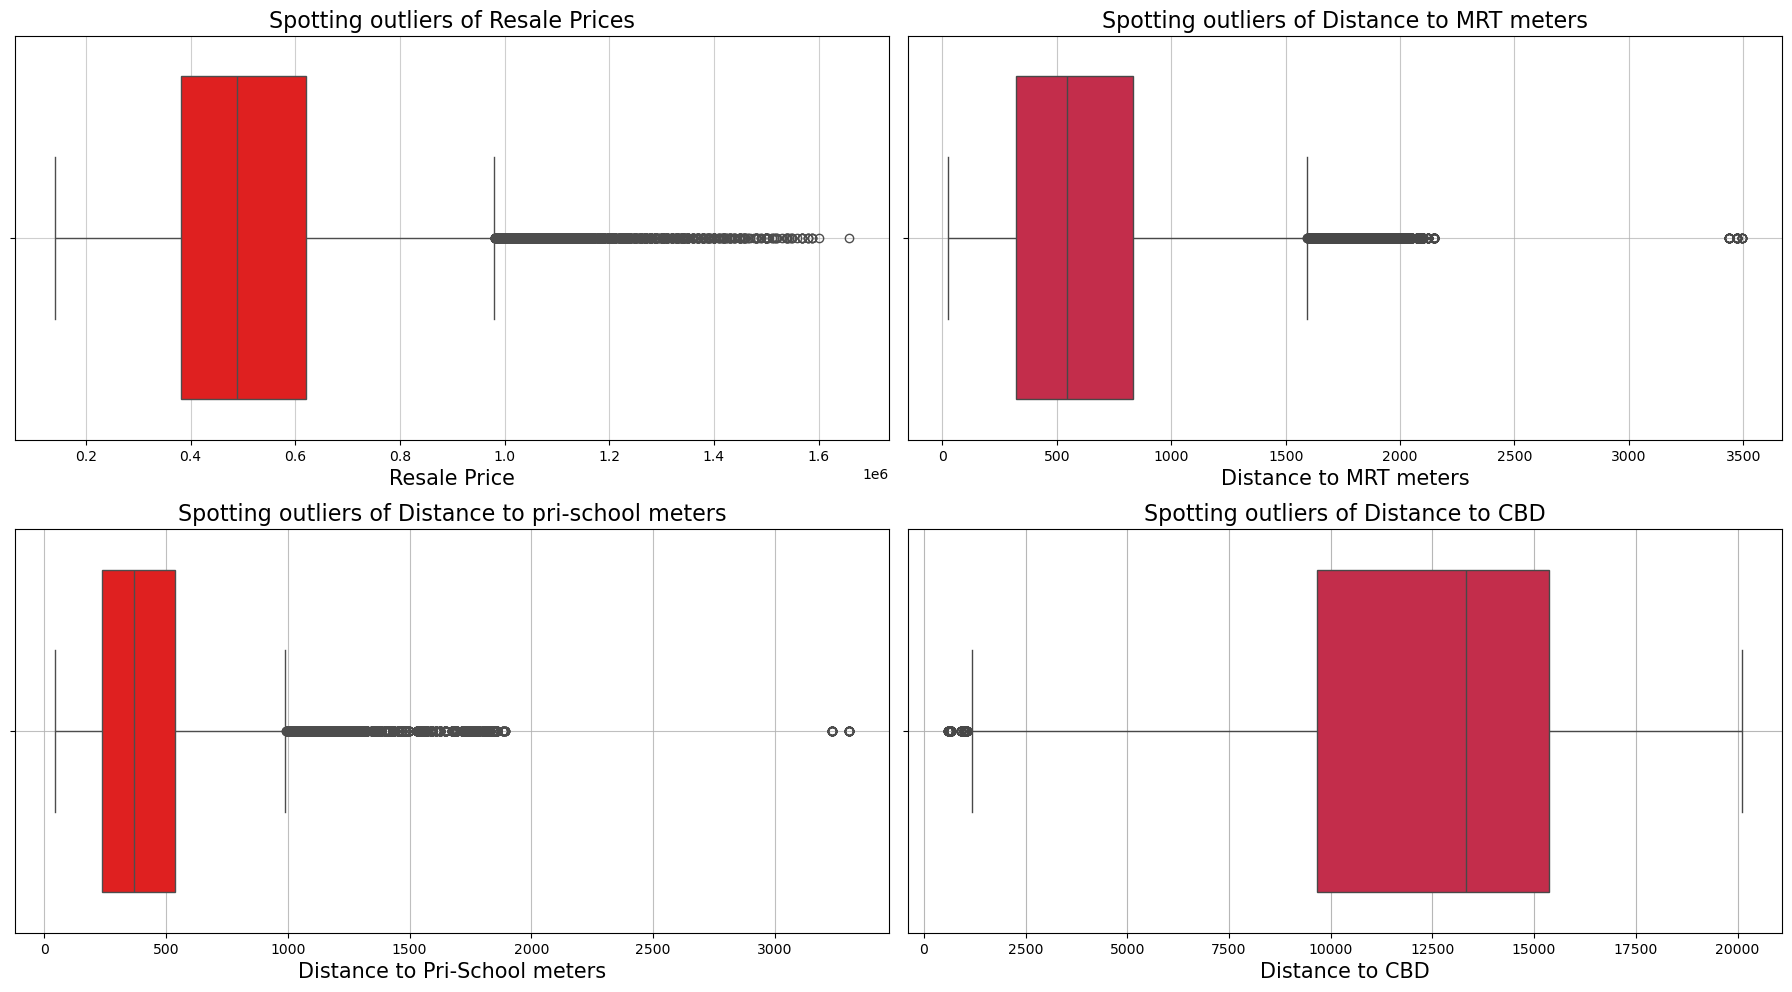

In [15]:
fig, ax = plt.subplots(2, 2, figsize=(18, 10))

ax1 = sns.boxplot(data=df, x='resale_price', color='red', ax=ax[0, 0]) 
ax1.set_title('Spotting outliers of Resale Prices', fontsize=16)

ax2 = sns.boxplot(data=df, x='distance_to_mrt_meters', color='crimson', ax=ax[0, 1])
ax2.set_title('Spotting outliers of Distance to MRT meters', fontsize=16)

ax3 = sns.boxplot(data=df, x='distance_to_pri_school_meters', color='red', ax=ax[1, 0])
ax3.set_title('Spotting outliers of Distance to pri-school meters', fontsize=16)

ax4 = sns.boxplot(data=df, x='distance_to_cbd', color='crimson', ax=ax[1, 1])
ax4.set_title('Spotting outliers of Distance to CBD', fontsize=16)

ax1.grid(True, alpha=0.6)
ax2.grid(True, alpha=0.7)
ax3.grid(True, alpha=0.8)
ax4.grid(True, alpha=0.9)

ax1.set_xlabel('Resale Price', fontsize=15)
ax2.set_xlabel('Distance to MRT meters', fontsize=15)
ax3.set_xlabel('Distance to Pri-School meters', fontsize=15)
ax4.set_xlabel('Distance to CBD', fontsize=15)

plt.tight_layout(pad=1)
plt.show()

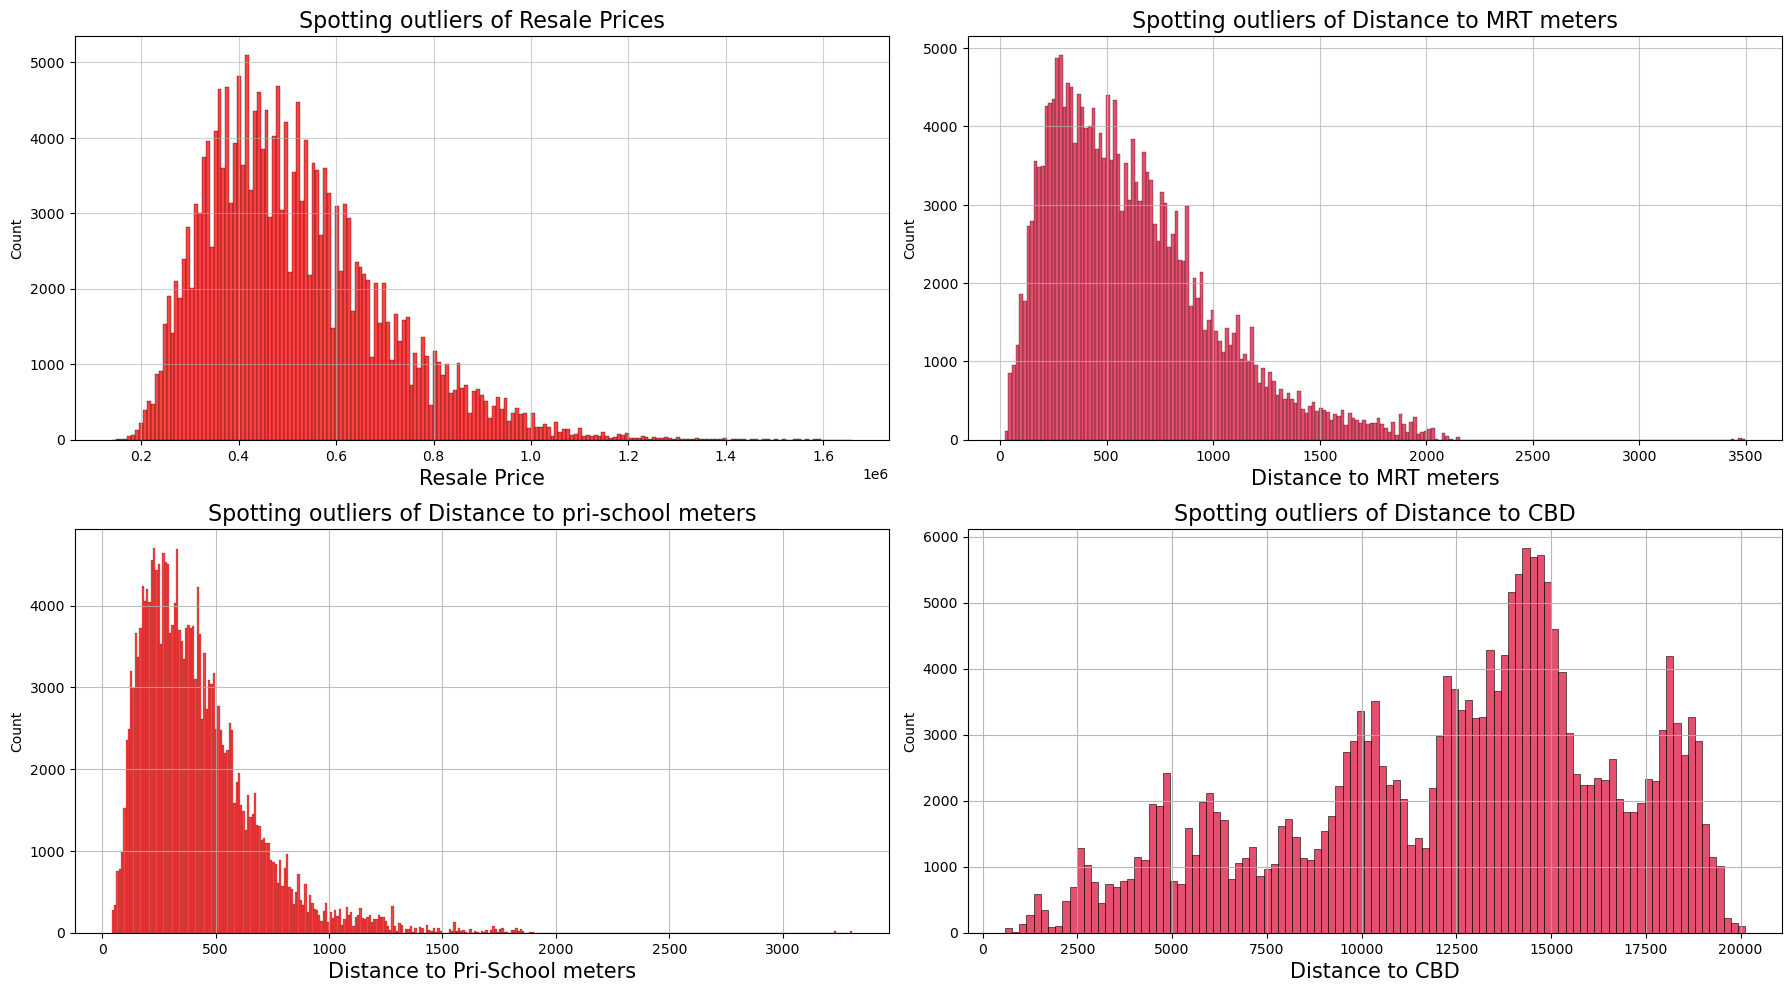

In [16]:
fig, ax = plt.subplots(2, 2, figsize=(18, 10))

ax1 = sns.histplot(data=df, x='resale_price', color='red', ax=ax[0, 0]) 
ax1.set_title('Spotting outliers of Resale Prices', fontsize=16)

ax2 = sns.histplot(data=df, x='distance_to_mrt_meters', color='crimson', ax=ax[0, 1])
ax2.set_title('Spotting outliers of Distance to MRT meters', fontsize=16)

ax3 = sns.histplot(data=df, x='distance_to_pri_school_meters', color='red', ax=ax[1, 0])
ax3.set_title('Spotting outliers of Distance to pri-school meters', fontsize=16)

ax4 = sns.histplot(data=df, x='distance_to_cbd', color='crimson', ax=ax[1, 1])
ax4.set_title('Spotting outliers of Distance to CBD', fontsize=16)

ax1.grid(True, alpha=0.6)
ax2.grid(True, alpha=0.7)
ax3.grid(True, alpha=0.8)
ax4.grid(True, alpha=0.9)

ax1.set_xlabel('Resale Price', fontsize=15)
ax2.set_xlabel('Distance to MRT meters', fontsize=15)
ax3.set_xlabel('Distance to Pri-School meters', fontsize=15)
ax4.set_xlabel('Distance to CBD', fontsize=15)

plt.tight_layout(pad=1)
plt.show()

*Resale Prices:*

Most resale prices are clustered between 400k–600k.

There are many high-value outliers above 1M, going up to around 1.6M.

Interpretation: Some flats are significantly more expensive than the majority.

.

*Distance to MRT (meters):*

Typical distances are within ~400–900 meters.

Outliers extend up to 3500 meters.

Interpretation: A few flats are much farther from MRT stations compared to the majority.

.

*Distance to Pre-School (meters):*

Majority are within 200–700 meters.

Outliers go beyond 2000–3000 meters.

Interpretation: Some flats are located unusually far from nearby pre-schools.

.

*Distance to CBD (meters):*

Most flats lie between 10,000–15,000 meters.

A few outliers are much closer (~1,000m) or farther (~20,000m).

Interpretation: Rare cases of flats either very close to or extremely far from the CBD.



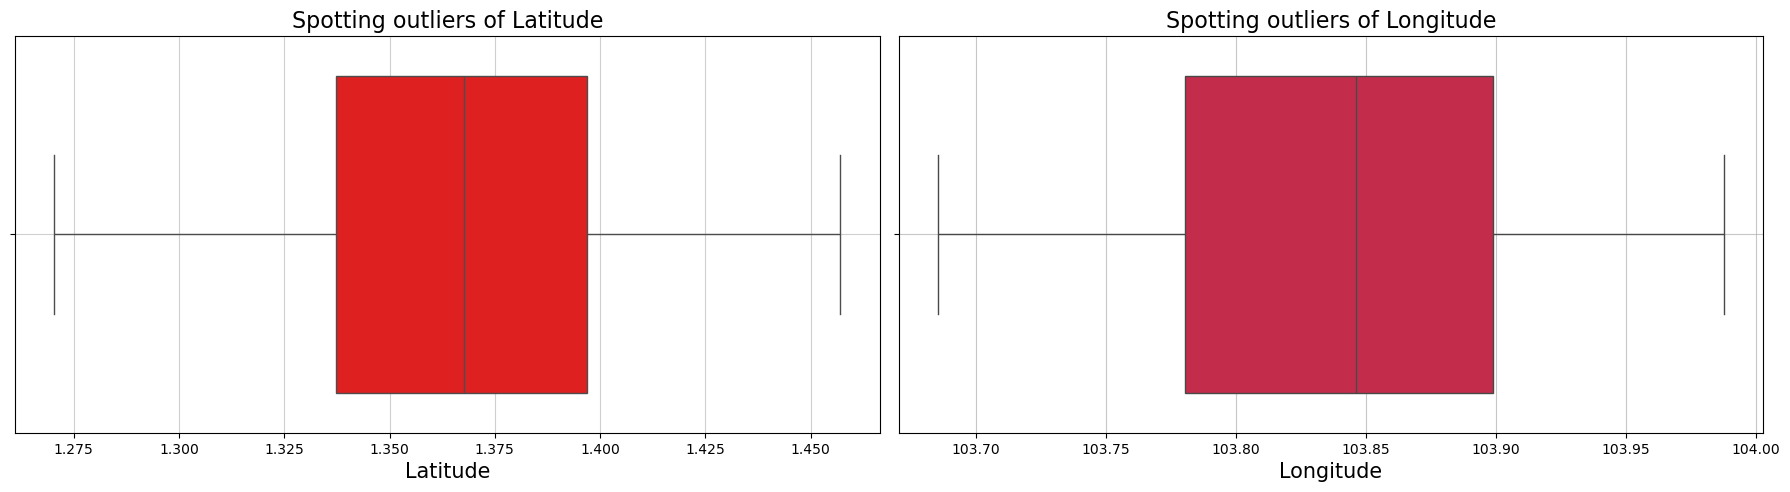

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(18, 5))

ax1 = sns.boxplot(data=df, x='latitude', color='red', ax=ax[0]) 
ax1.set_title('Spotting outliers of Latitude', fontsize=16)

ax2 = sns.boxplot(data=df, x='longitude', color='crimson', ax=ax[1])
ax2.set_title('Spotting outliers of Longitude', fontsize=16)

ax1.grid(True, alpha=0.6)
ax2.grid(True, alpha=0.7)

ax1.set_xlabel('Latitude', fontsize=15)
ax2.set_xlabel('Longitude', fontsize=15)

plt.tight_layout(pad=1)
plt.show()

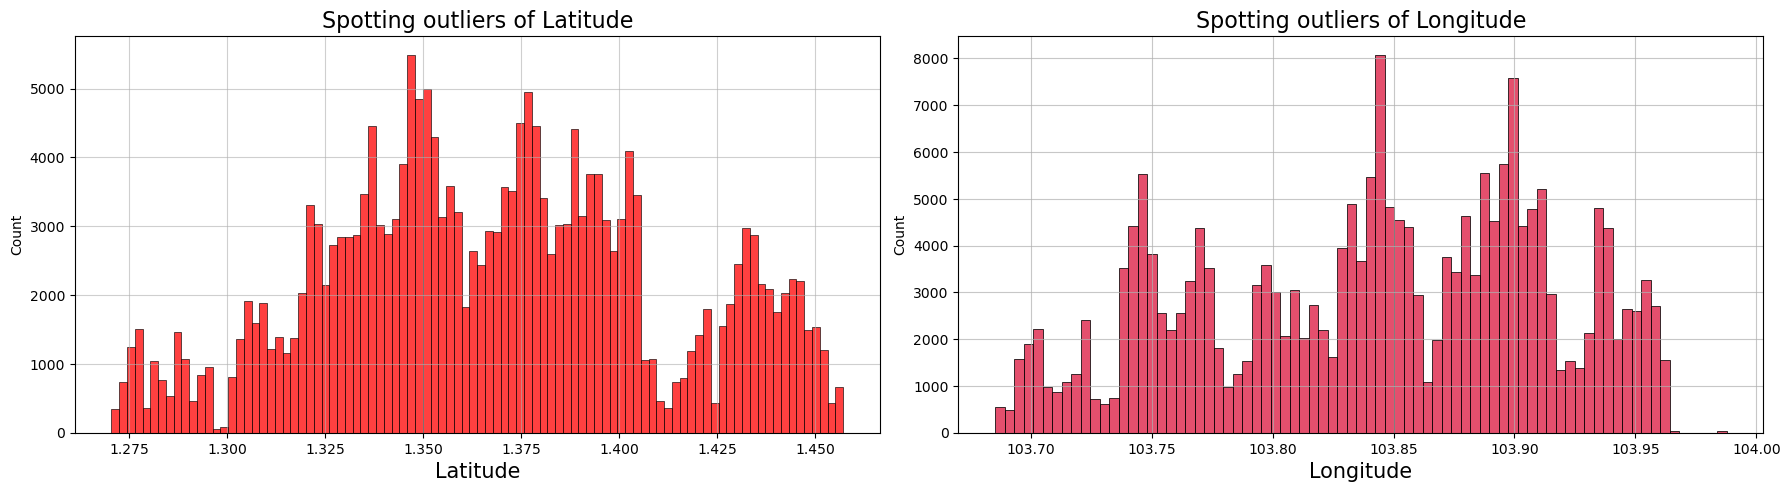

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(18, 5))

ax1 = sns.histplot(data=df, x='latitude', color='red', ax=ax[0]) 
ax1.set_title('Spotting outliers of Latitude', fontsize=16)

ax2 = sns.histplot(data=df, x='longitude', color='crimson', ax=ax[1])
ax2.set_title('Spotting outliers of Longitude', fontsize=16)

ax1.grid(True, alpha=0.6)
ax2.grid(True, alpha=0.7)

ax1.set_xlabel('Latitude', fontsize=15)
ax2.set_xlabel('Longitude', fontsize=15)

plt.tight_layout(pad=1)
plt.show()

*Latitude:*

Most values are concentrated between 1.33 and 1.40.

.

*Longitude:*

Typical range is 103.80 to 103.90.

```
Find Bivariate Outliers!

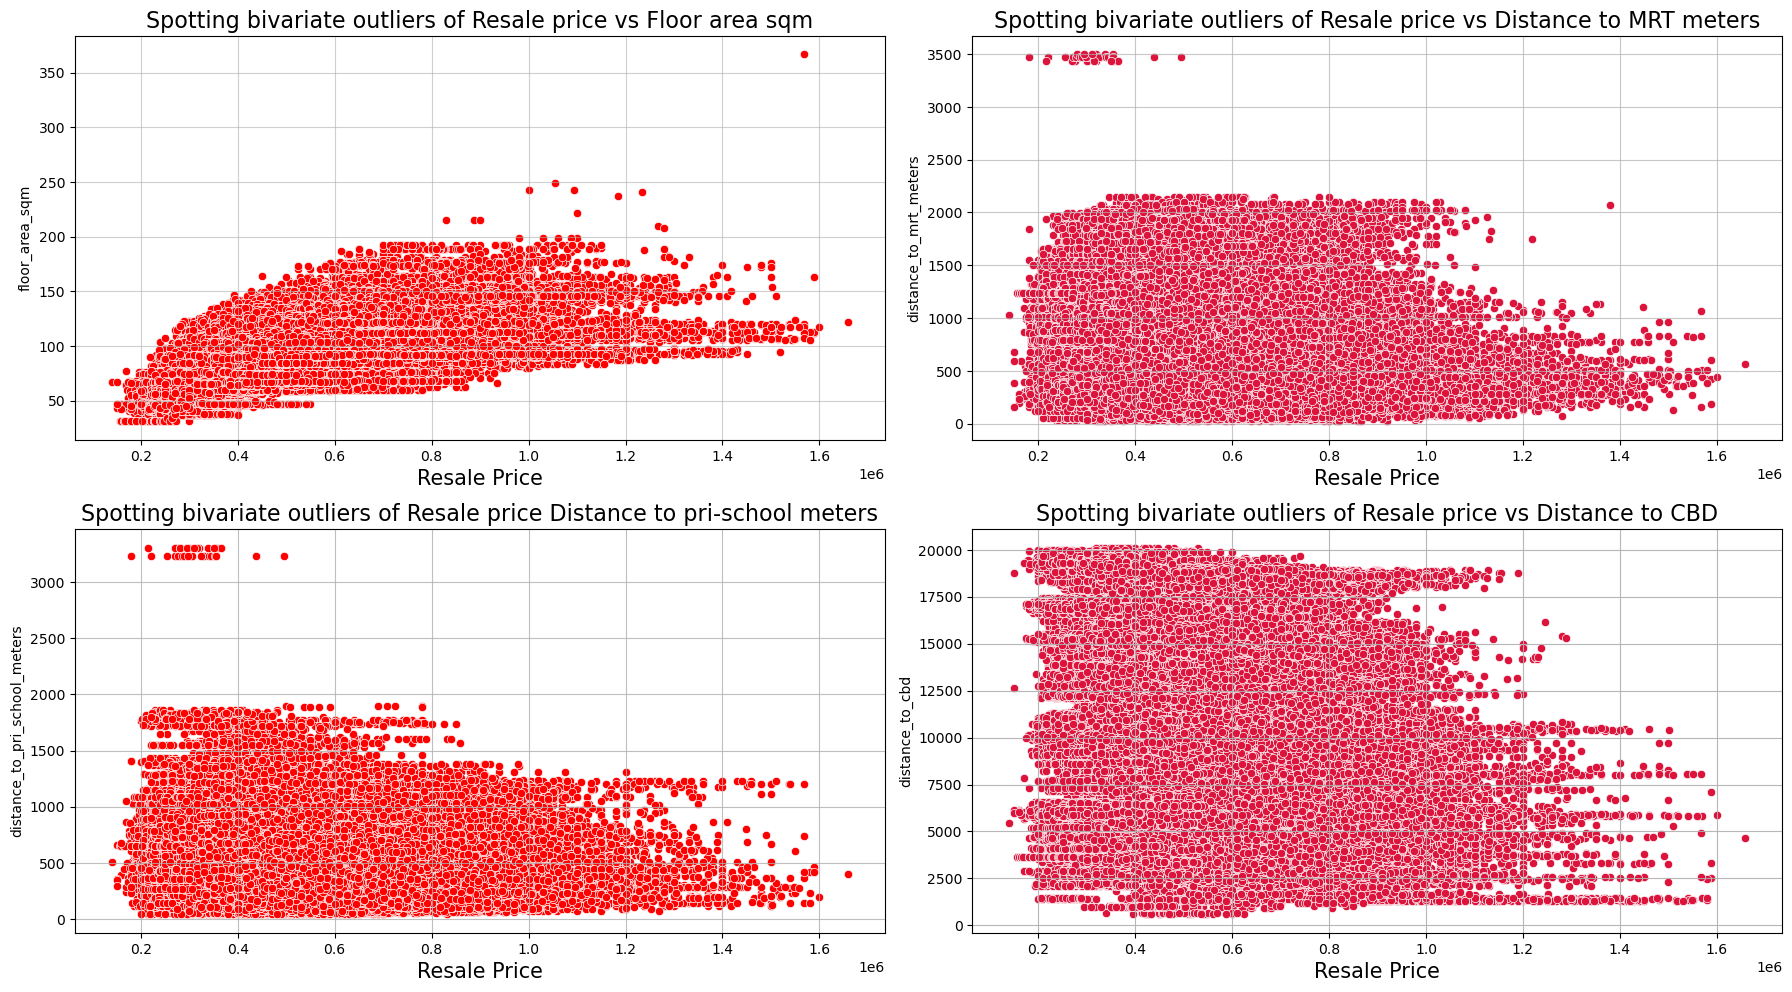

In [19]:
fig, ax = plt.subplots(2, 2, figsize=(18, 10))

ax1 = sns.scatterplot(data=df, x='resale_price', y='floor_area_sqm', color='red', ax=ax[0, 0]) 
ax1.set_title('Spotting bivariate outliers of Resale price vs Floor area sqm', fontsize=16)

ax2 = sns.scatterplot(data=df, x='resale_price', y='distance_to_mrt_meters', color='crimson', ax=ax[0, 1])
ax2.set_title('Spotting bivariate outliers of Resale price vs Distance to MRT meters', fontsize=16)

ax3 = sns.scatterplot(data=df, x='resale_price', y='distance_to_pri_school_meters', color='red', ax=ax[1, 0])
ax3.set_title('Spotting bivariate outliers of Resale price Distance to pri-school meters', fontsize=16)

ax4 = sns.scatterplot(data=df, x='resale_price', y='distance_to_cbd', color='crimson', ax=ax[1, 1])
ax4.set_title('Spotting bivariate outliers of Resale price vs Distance to CBD', fontsize=16)

ax1.grid(True, alpha=0.6)
ax2.grid(True, alpha=0.7)
ax3.grid(True, alpha=0.8)
ax4.grid(True, alpha=0.9)

ax1.set_xlabel('Resale Price', fontsize=15)
ax2.set_xlabel('Resale Price', fontsize=15)
ax3.set_xlabel('Resale Price', fontsize=15)
ax4.set_xlabel('Resale Price', fontsize=15)

plt.tight_layout(pad=1)
plt.show()

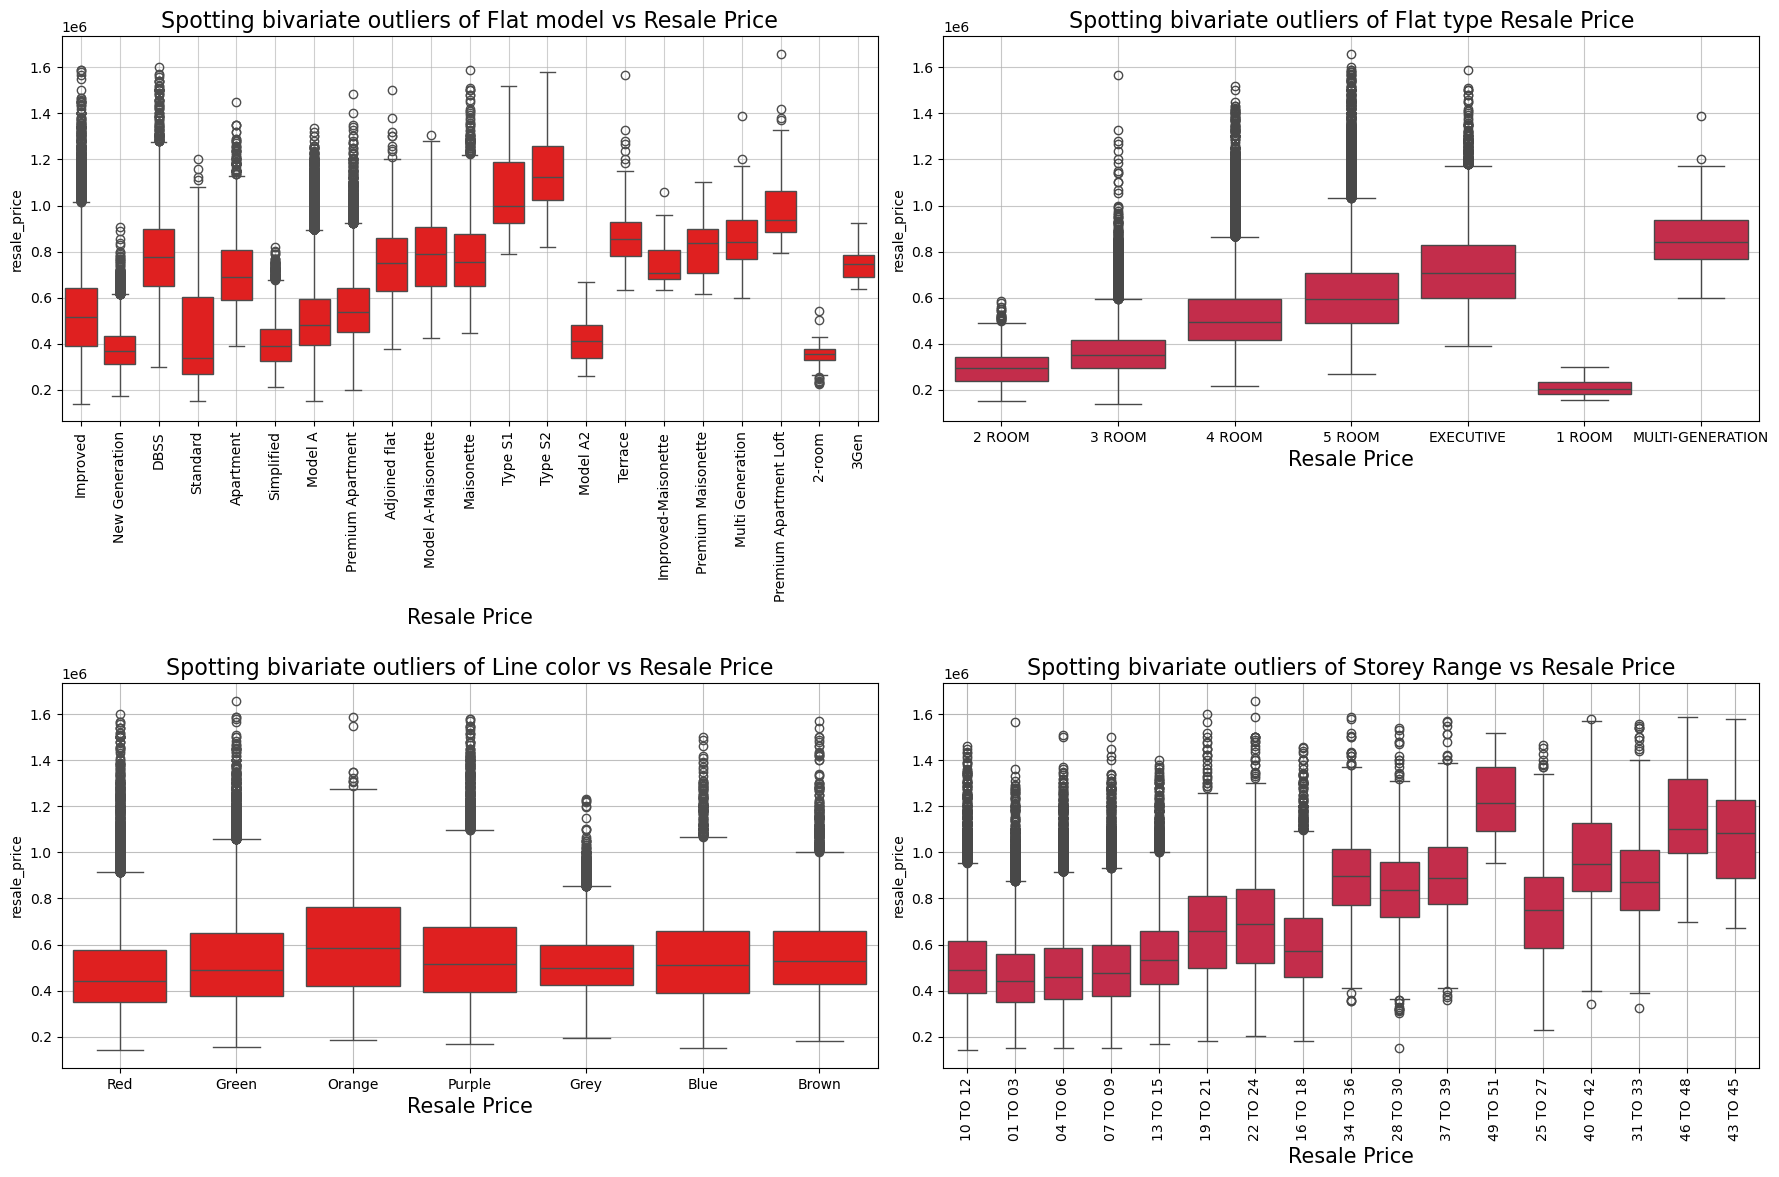

In [20]:
fig, ax = plt.subplots(2, 2, figsize=(18, 12))

ax1 = sns.boxplot(data=df, x='flat_model', y='resale_price', color='red', ax=ax[0, 0]) 
ax1.set_title('Spotting bivariate outliers of Flat model vs Resale Price', fontsize=16)

ax2 = sns.boxplot(data=df, x='flat_type', y='resale_price', color='crimson', ax=ax[0, 1])
ax2.set_title('Spotting bivariate outliers of Flat type Resale Price', fontsize=16)

ax3 = sns.boxplot(data=df, x='line_color', y='resale_price', color='red', ax=ax[1, 0])
ax3.set_title('Spotting bivariate outliers of Line color vs Resale Price', fontsize=16)

ax4 = sns.boxplot(data=df, x='storey_range', y='resale_price', color='crimson', ax=ax[1, 1])
ax4.set_title('Spotting bivariate outliers of Storey Range vs Resale Price', fontsize=16)

ax1.grid(True, alpha=0.6)
ax2.grid(True, alpha=0.7)
ax3.grid(True, alpha=0.8)
ax4.grid(True, alpha=0.9)

ax1.set_xlabel('Resale Price', fontsize=15)
ax2.set_xlabel('Resale Price', fontsize=15)
ax3.set_xlabel('Resale Price', fontsize=15)
ax4.set_xlabel('Resale Price', fontsize=15)

ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=90)
plt.tight_layout(pad=1)
plt.show()

In [21]:
sc = StandardScaler()
x = df.select_dtypes(['int64', 'float64'])
x_scaled = sc.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)

In [22]:
mean = x_scaled.mean()
cov = x_scaled.cov()
inv_cov = np.linalg.inv(cov)

distances = []

for _, x in x_scaled.iterrows():
    d = mahalanobis(x, mean, inv_cov)
    distances.append(d)

df['mahalanobis_distances'] = distances
df.head()

,resale_price,storey_range,flat_type,flat_model,remaining_lease_months,floor_area_sqm,planning_area_ura,region_ura,latitude,longitude,closest_mrt_station,distance_to_mrt_meters,transport_type,line_color,distance_to_cbd,closest_pri_school,distance_to_pri_school_meters,total_lease_remaining_years,mahalanobis_distances
0,232000.0,10 TO 12,2 ROOM,Improved,4,44.0,ANG MO KIO,NORTH-EAST REGION,1.362005,103.853880,Ang Mo Kio,999.941618,MRT,Red,8615.656983,TOWNSVILLE PRIMARY SCHOOL,218.125254,61.333333,3.034168
1,250000.0,01 TO 03,3 ROOM,New Generation,7,67.0,ANG MO KIO,NORTH-EAST REGION,1.370966,103.838202,Ang Mo Kio,1268.958246,MRT,Red,9715.131951,ANG MO KIO PRIMARY SCHOOL,241.572335,60.583333,2.943351
2,262000.0,01 TO 03,3 ROOM,New Generation,5,67.0,ANG MO KIO,NORTH-EAST REGION,1.380709,103.835368,Yio Chu Kang,1072.295164,MRT,Red,10828.819556,ANDERSON PRIMARY SCHOOL,777.155378,62.416667,2.572860
3,265000.0,04 TO 06,3 ROOM,New Generation,1,68.0,ANG MO KIO,NORTH-EAST REGION,1.366201,103.857201,Ang Mo Kio,945.371842,MRT,Red,9097.929095,TECK GHEE PRIMARY SCHOOL,698.165530,62.083333,2.685572
4,265000.0,01 TO 03,3 ROOM,New Generation,5,67.0,ANG MO KIO,NORTH-EAST REGION,1.381041,103.835132,Yio Chu Kang,1095.197729,MRT,Red,10869.453109,ANDERSON PRIMARY SCHOOL,782.553222,62.416667,2.599838


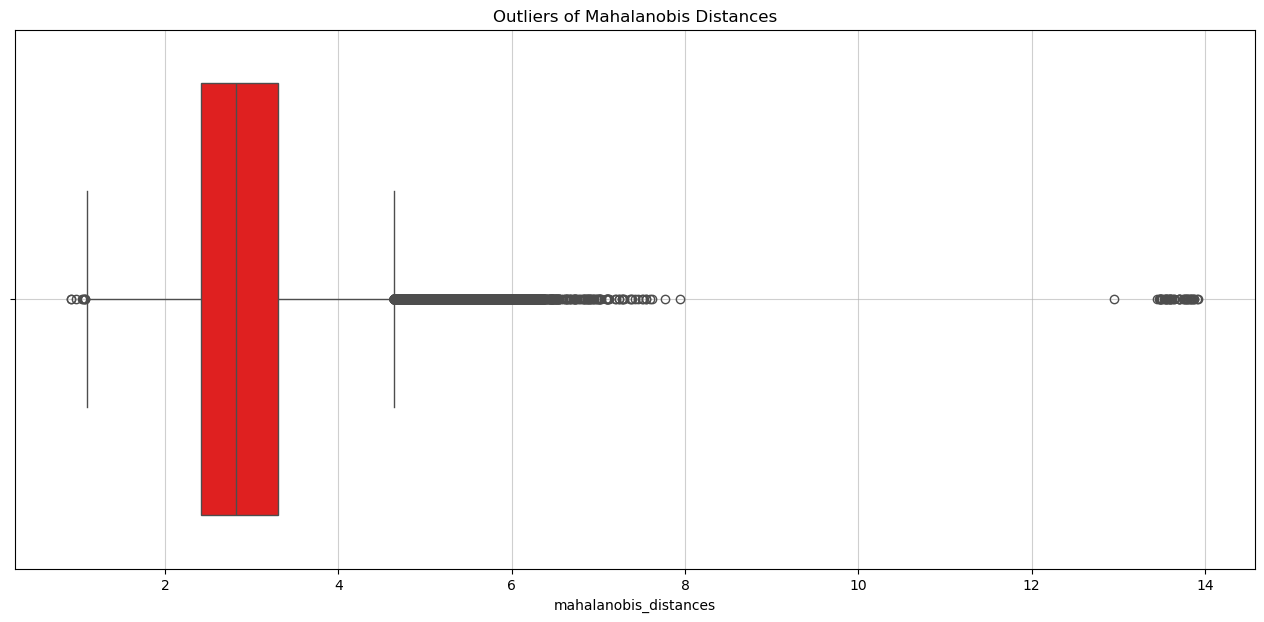

In [23]:
plt.figure(figsize=(16, 7))

sns.boxplot(data=df, x='mahalanobis_distances', color='red')
plt.title('Outliers of Mahalanobis Distances')
plt.grid(True, alpha=0.6)
plt.show()

In [24]:
mahalanobis_outliers = df[df['mahalanobis_distances'] > 4.2]
mahalanobis_outliers.head(15)

,resale_price,storey_range,flat_type,flat_model,remaining_lease_months,floor_area_sqm,planning_area_ura,region_ura,latitude,longitude,closest_mrt_station,distance_to_mrt_meters,transport_type,line_color,distance_to_cbd,closest_pri_school,distance_to_pri_school_meters,total_lease_remaining_years,mahalanobis_distances
142,728888.0,22 TO 24,5 ROOM,Improved,0,120.0,BISHAN,CENTRAL REGION,1.362769,103.832759,Marymount,1722.684196,MRT,Orange,8941.601385,AI TONG SCHOOL,243.399261,68.000000,4.234172
300,400000.0,16 TO 18,3 ROOM,Improved,9,68.0,ROCHOR,CENTRAL REGION,1.299009,103.852285,Bras Basah,298.002130,MRT,Orange,1648.322689,FARRER PARK PRIMARY SCHOOL,1486.833416,68.750000,5.288228
303,470000.0,16 TO 18,3 ROOM,Improved,2,68.0,ROCHOR,CENTRAL REGION,1.300933,103.853991,Bugis,197.821139,MRT,Green,1879.635339,FARRER PARK PRIMARY SCHOOL,1314.470978,61.166667,4.582019
304,685000.0,16 TO 18,4 ROOM,Improved,4,82.0,DOWNTOWN CORE,CENTRAL REGION,1.296853,103.853348,Bras Basah,298.280009,MRT,Orange,1422.904658,FARRER PARK PRIMARY SCHOOL,1739.513618,62.333333,5.814892
306,818000.0,04 TO 06,4 ROOM,Type S1,0,95.0,OUTRAM,CENTRAL REGION,1.275987,103.841192,Outram Park,456.566340,MRT,Purple,1454.726680,CANTONMENT PRIMARY SCHOOL,148.149721,93.000000,4.206118
307,903000.0,37 TO 39,4 ROOM,Type S1,0,95.0,OUTRAM,CENTRAL REGION,1.275987,103.841192,Outram Park,456.566340,MRT,Purple,1454.726680,CANTONMENT PRIMARY SCHOOL,148.149721,93.000000,4.268890
308,1108000.0,49 TO 51,5 ROOM,Type S2,0,105.0,OUTRAM,CENTRAL REGION,1.277799,103.841403,Outram Park,304.768216,MRT,Purple,1319.997748,CANTONMENT PRIMARY SCHOOL,303.170508,93.000000,4.536261
370,397000.0,01 TO 03,4 ROOM,New Generation,8,92.0,CLEMENTI,WEST REGION,1.301918,103.763073,Clementi,1478.323821,MRT,Green,10031.667397,QIFA PRIMARY SCHOOL,1437.617334,63.666667,4.546113
372,440000.0,01 TO 03,4 ROOM,Model A,9,103.0,CLEMENTI,WEST REGION,1.303697,103.769477,Dover,1328.853733,MRT,Green,9377.340431,PEI TONG PRIMARY SCHOOL,1397.934820,65.750000,4.463888
373,461000.0,10 TO 12,4 ROOM,New Generation,8,91.0,CLEMENTI,WEST REGION,1.301918,103.763073,Clementi,1478.323821,MRT,Green,10031.667397,QIFA PRIMARY SCHOOL,1437.617334,63.666667,4.442929


In [25]:
x_scaled.isnull().sum()

resale_price                     0
remaining_lease_months           0
floor_area_sqm                   0
latitude                         0
longitude                        0
distance_to_mrt_meters           0
distance_to_cbd                  0
distance_to_pri_school_meters    0
total_lease_remaining_years      0
dtype: int64

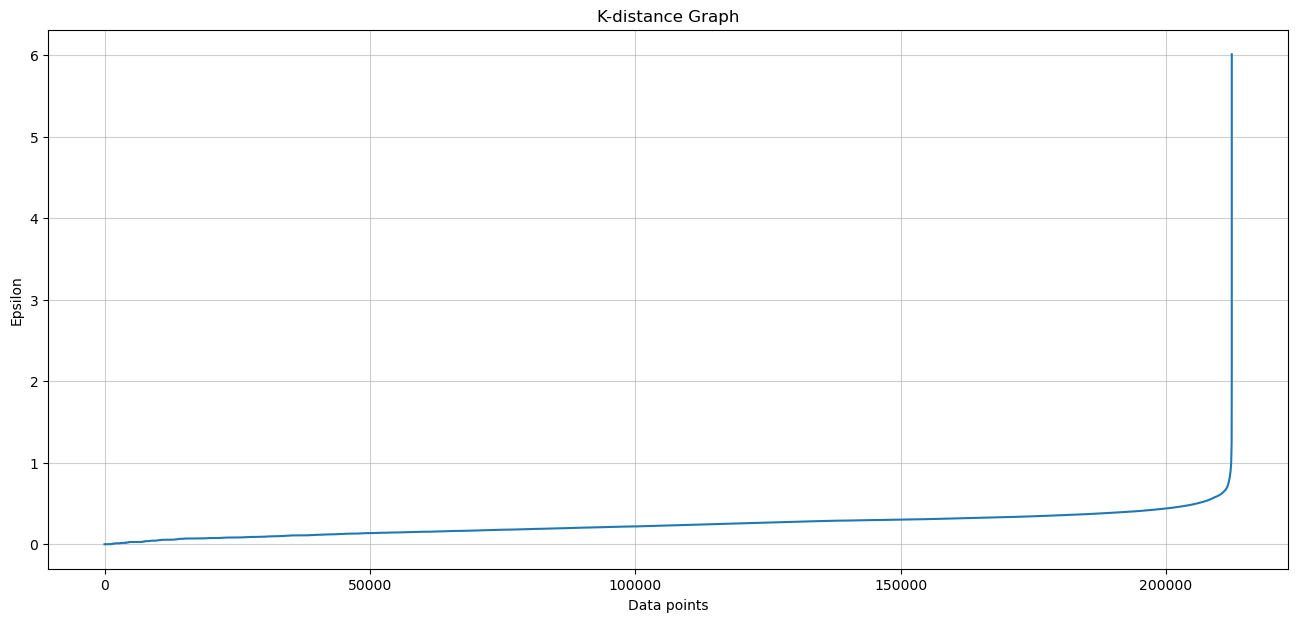

In [26]:
knn = NearestNeighbors(n_neighbors=2)
nbrs = knn.fit(x_scaled)

distances, indices = nbrs.kneighbors(x_scaled)

distances = np.sort(distances, axis=0)
distances = distances[:, 1]

plt.figure(figsize=(16, 7))
plt.plot(distances)
plt.title('K-distance Graph')
plt.xlabel('Data points')
plt.ylabel('Epsilon')
plt.grid(True, alpha=0.6)
plt.show()

In [27]:
dbscan = DBSCAN(eps=0.6, min_samples=6)
dbscan.fit(x_scaled)
labels = dbscan.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
outlier_indices = np.where(labels == -1)[0]
print('Number of Clusters: ', n_clusters)

Number of Clusters:  766


In [28]:
print('Number of Outliers: ', len(outlier_indices))

Number of Outliers:  9038


In [29]:
df.loc[outlier_indices, :].head()

,resale_price,storey_range,flat_type,flat_model,remaining_lease_months,floor_area_sqm,planning_area_ura,region_ura,latitude,longitude,closest_mrt_station,distance_to_mrt_meters,transport_type,line_color,distance_to_cbd,closest_pri_school,distance_to_pri_school_meters,total_lease_remaining_years,mahalanobis_distances
38,430000.0,04 TO 06,4 ROOM,New Generation,6,97.0,ANG MO KIO,NORTH-EAST REGION,1.370203,103.834688,Ang Mo Kio,1655.162403,MRT,Red,9699.382984,ANG MO KIO PRIMARY SCHOOL,558.683151,59.500000,3.236574
52,725000.0,13 TO 15,5 ROOM,Improved,5,119.0,ANG MO KIO,NORTH-EAST REGION,1.371478,103.845869,Ang Mo Kio,444.702150,MRT,Red,9678.995683,MAYFLOWER PRIMARY SCHOOL,614.978852,62.416667,2.319701
56,238000.0,04 TO 06,2 ROOM,Improved,6,45.0,BEDOK,EAST REGION,1.334485,103.937925,Tanah Merah,1236.929513,MRT,Green,11117.582991,ST. ANTHONY'S CANOSSIAN PRIMARY SCHOOL,369.346623,60.500000,3.593137
61,281000.0,04 TO 06,3 ROOM,Simplified,8,63.0,BEDOK,EAST REGION,1.335576,103.911546,Kembangan,1615.101706,MRT,Green,8779.496972,TELOK KURAU PRIMARY SCHOOL,505.547741,70.666667,3.429021
64,287000.0,10 TO 12,3 ROOM,New Generation,7,70.0,BEDOK,EAST REGION,1.329144,103.909113,Kembangan,992.778790,MRT,Green,8120.678101,TELOK KURAU PRIMARY SCHOOL,292.041714,67.583333,2.467671


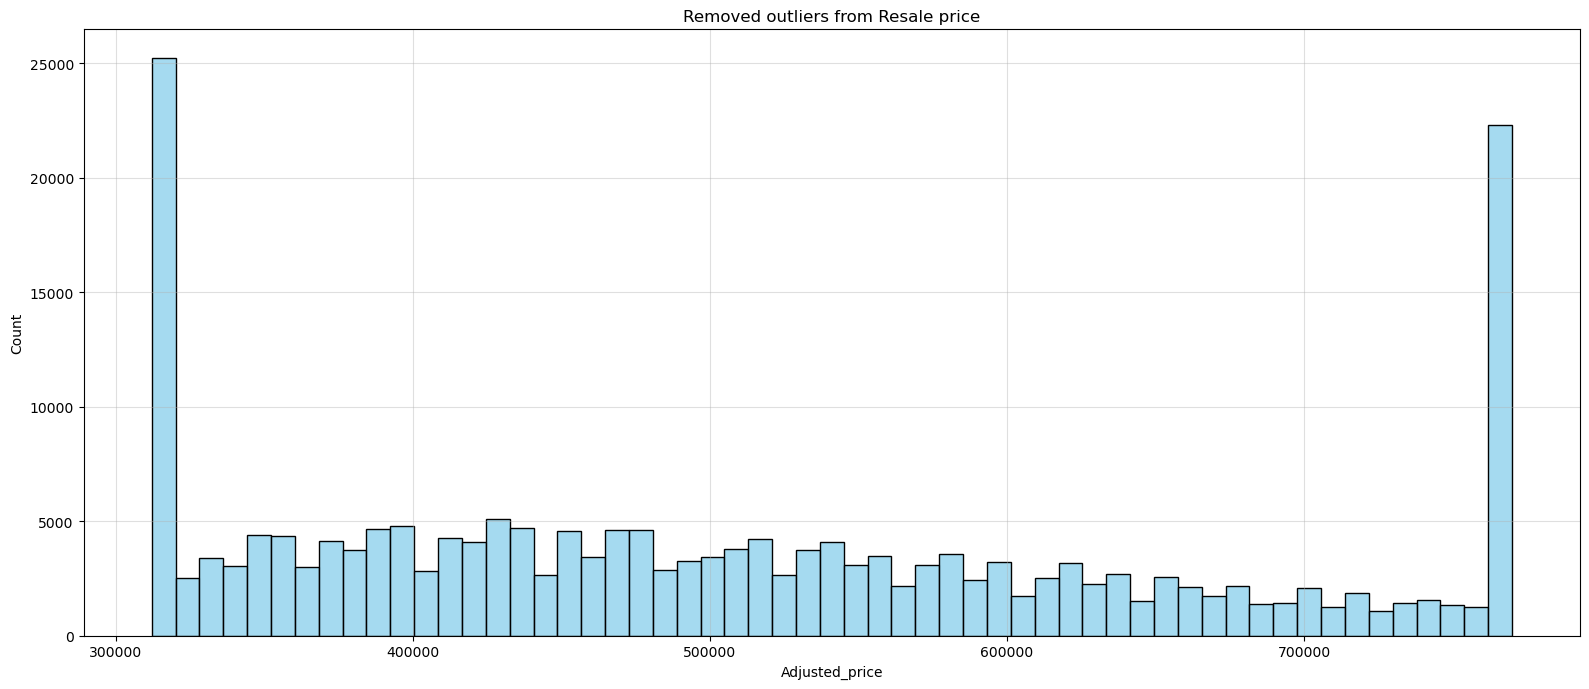

In [30]:
floor_thresh = df['resale_price'].quantile(0.10)
cap_thresh = df['resale_price'].quantile(0.90)

df['Adjusted_price'] = df['resale_price']
df.loc[df['resale_price'] < floor_thresh, 'Adjusted_price'] = floor_thresh
df.loc[df['resale_price'] > cap_thresh, 'Adjusted_price'] = cap_thresh

plt.figure(figsize=(16, 7))
ax = sns.histplot(data=df, x='Adjusted_price', color='skyblue')
plt.title('Removed outliers from Resale price')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

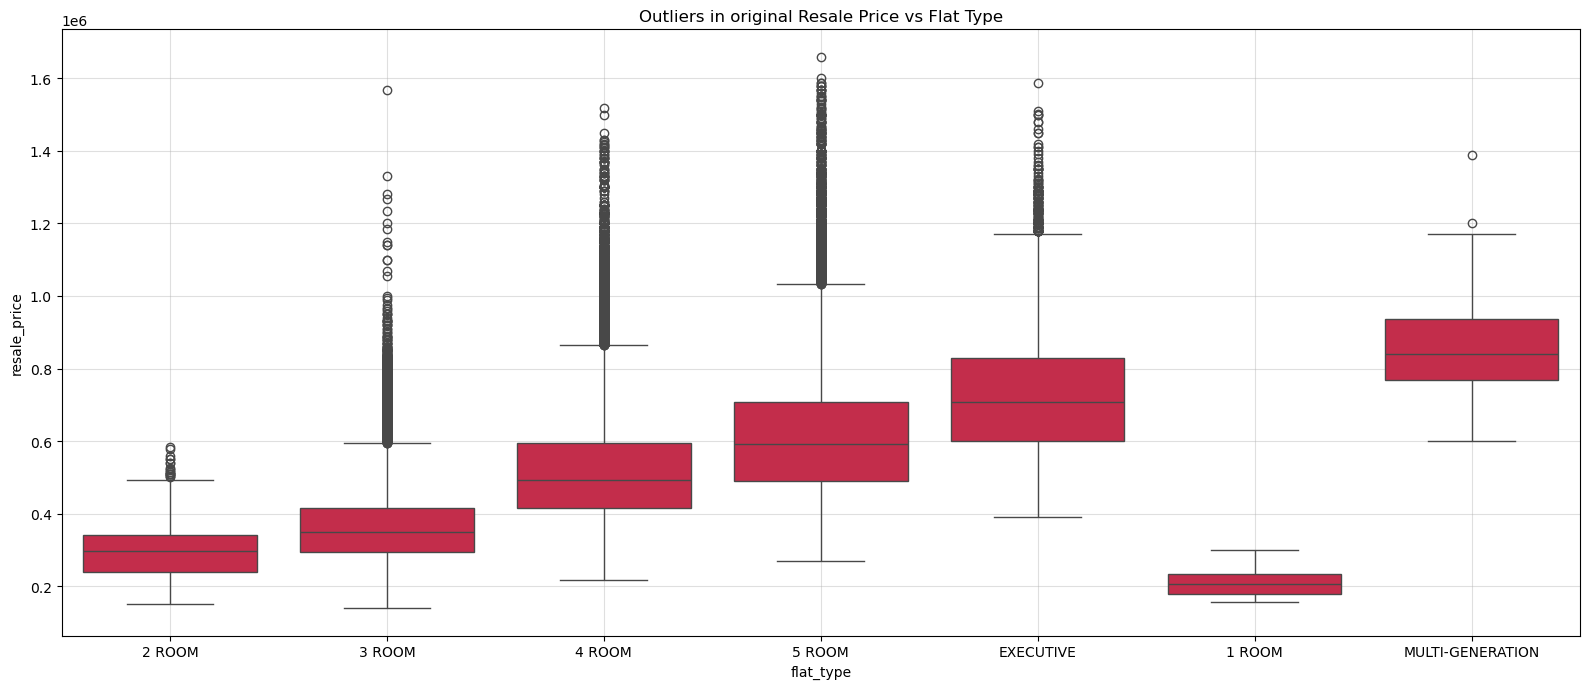

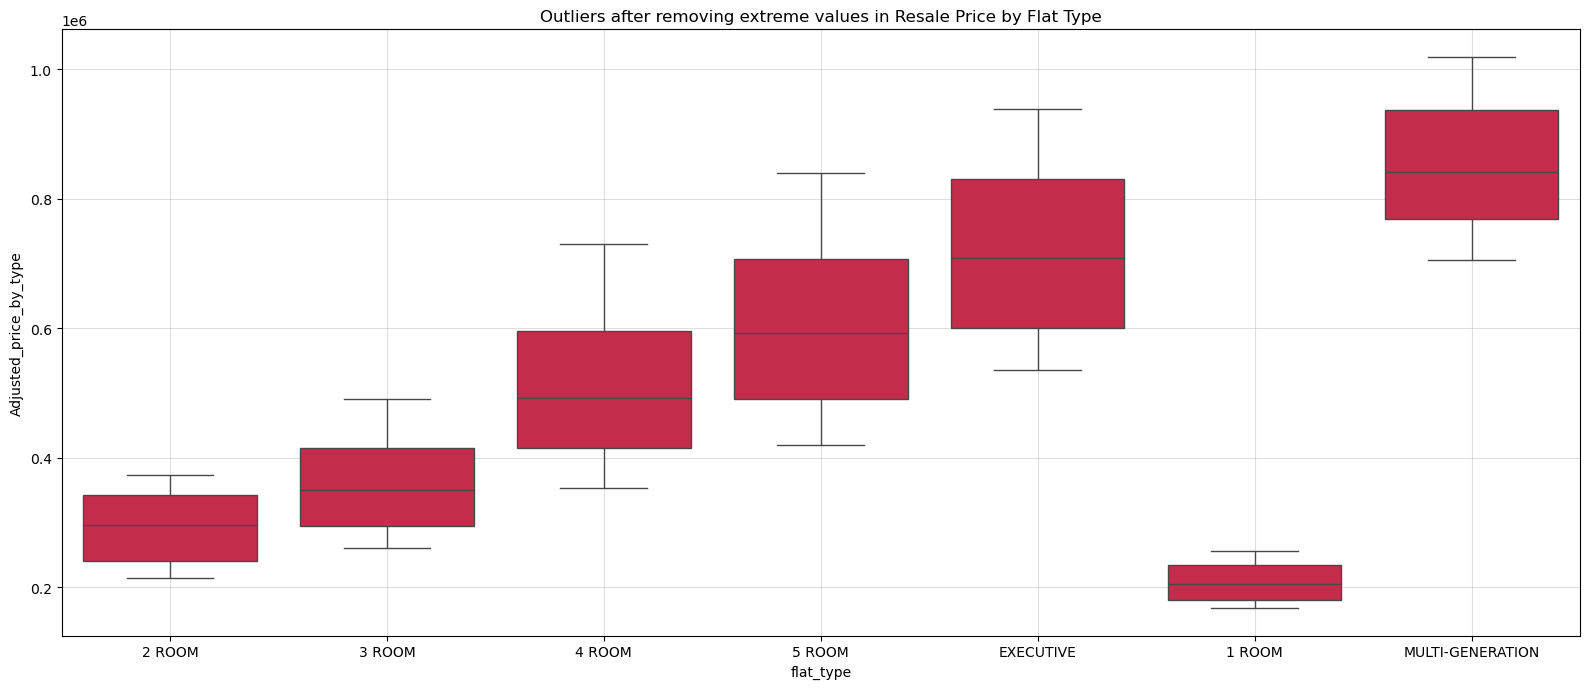

In [72]:
df['90_perc'] = df.groupby('flat_type')['resale_price'].transform(lambda x: np.nanpercentile(x, 90))
df['10_perc'] = df.groupby('flat_type')['resale_price'].transform(lambda x: np.nanpercentile(x, 10))

df['Adjusted_price_by_type'] = df['resale_price']
df.loc[df['resale_price'] < df['10_perc'], 'Adjusted_price_by_type'] = df['10_perc']
df.loc[df['resale_price'] > df['90_perc'], 'Adjusted_price_by_type'] = df['90_perc']

plt.figure(figsize=(16, 7))
sns.boxplot(data=df, x='flat_type', y='resale_price', color='crimson')
plt.title('Outliers in original Resale Price vs Flat Type')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print()

plt.figure(figsize=(16, 7))
sns.boxplot(data=df, x='flat_type', y='Adjusted_price_by_type', color='crimson')
plt.title('Outliers after removing extreme values in Resale Price by Flat Type')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

The first boxplot shows the **distribution of resale prices** across different flat types, highlighting the presence of **extreme outliers**, particularly in 3-ROOM, 4-ROOM, 5-ROOM, and EXECUTIVE flats. These outliers can distort statistical analysis and model predictions.

The second boxplot demonstrates the **effect after removing extreme values**, using a group-adjusted approach. We can see a **cleaner distribution**, with reduced skewness and more consistent interquartile ranges across flat types. This preprocessing step ensures a more robust and reliable dataset for downstream analysis, such as regression or predictive modeling

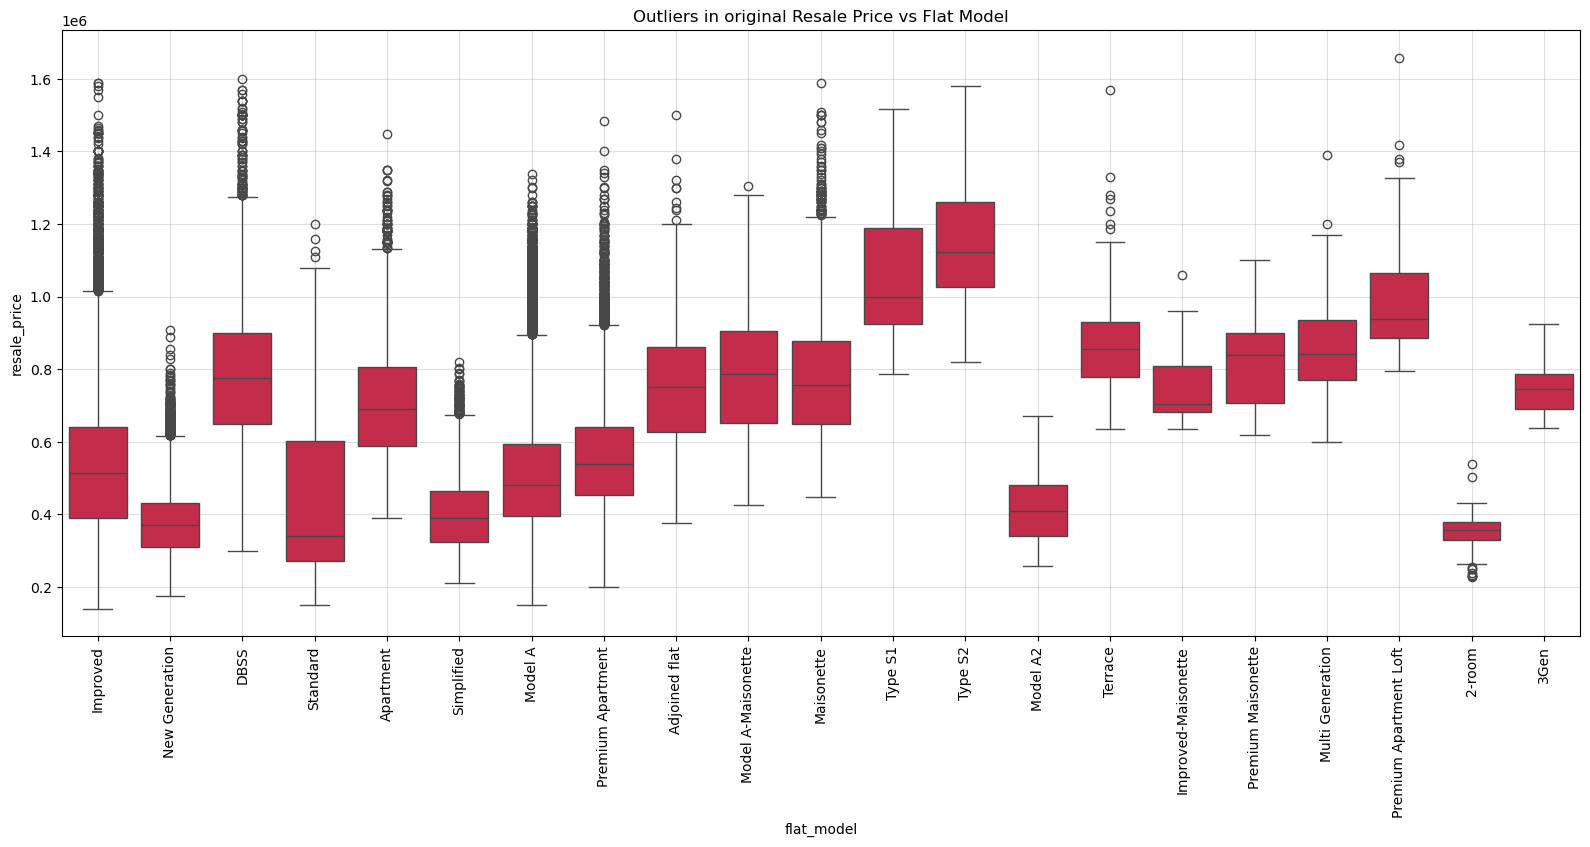

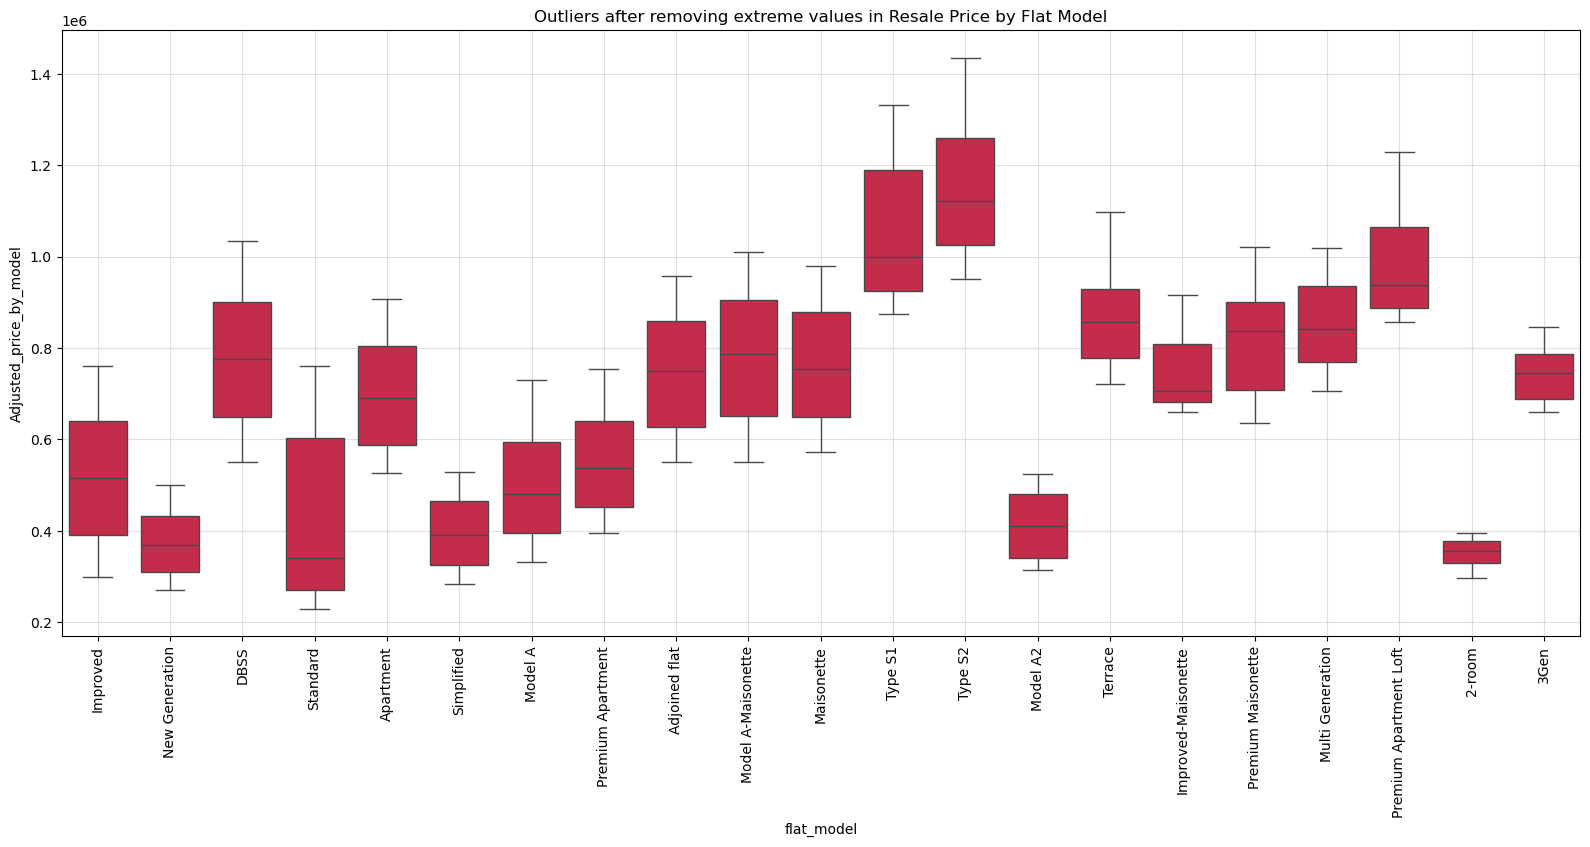

In [73]:
df['90_perc'] = df.groupby('flat_model')['resale_price'].transform(lambda x: np.nanpercentile(x, 90))
df['10_perc'] = df.groupby('flat_model')['resale_price'].transform(lambda x: np.nanpercentile(x, 10))

df['Adjusted_price_by_model'] = df['resale_price']
df.loc[df['resale_price'] < df['10_perc'], 'Adjusted_price_by_model'] = df['10_perc']
df.loc[df['resale_price'] > df['90_perc'], 'Adjusted_price_by_model'] = df['90_perc']

plt.figure(figsize=(16, 7))
sns.boxplot(data=df, x='flat_model', y='resale_price', color='crimson')
plt.title('Outliers in original Resale Price vs Flat Model')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

print()

plt.figure(figsize=(16, 7))
sns.boxplot(data=df, x='flat_model', y='Adjusted_price_by_model', color='crimson')
plt.title('Outliers after removing extreme values in Resale Price by Flat Model')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

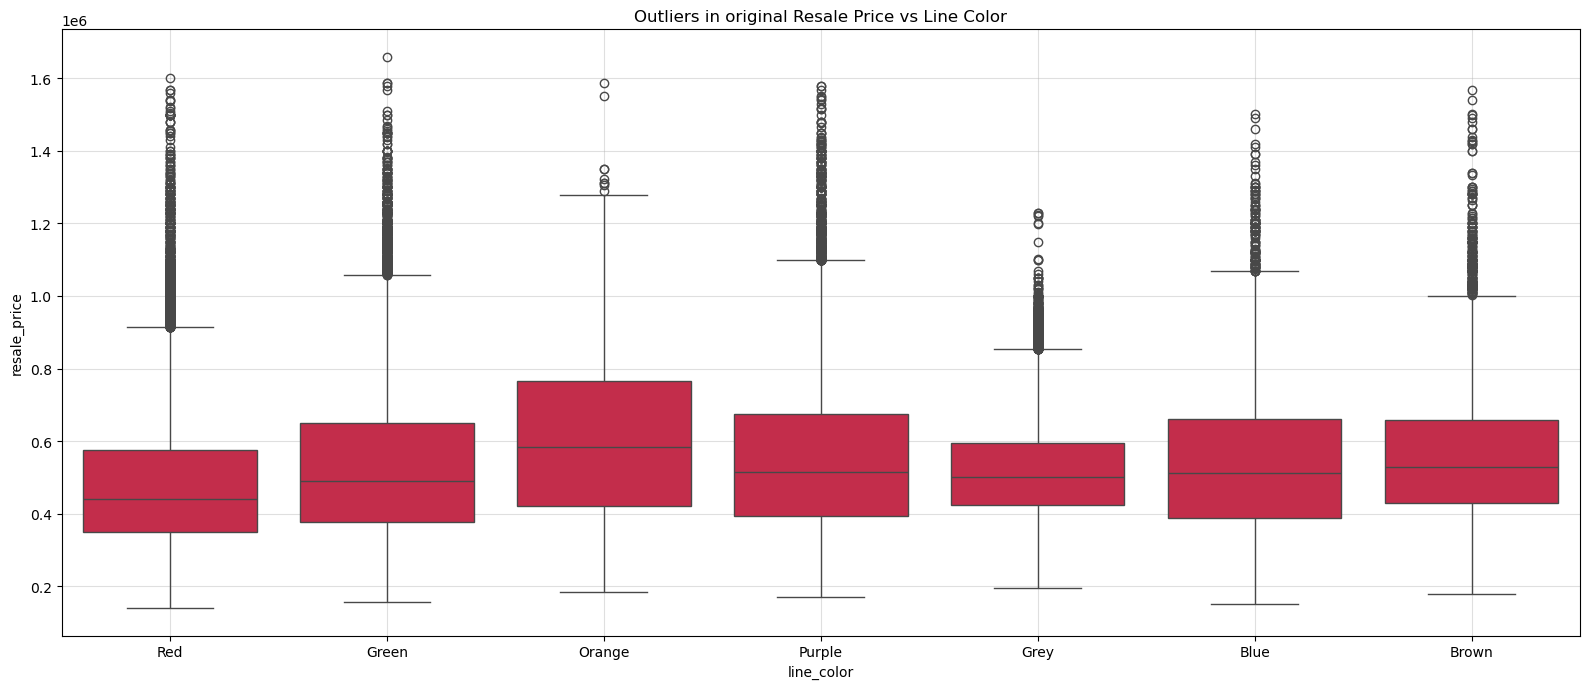

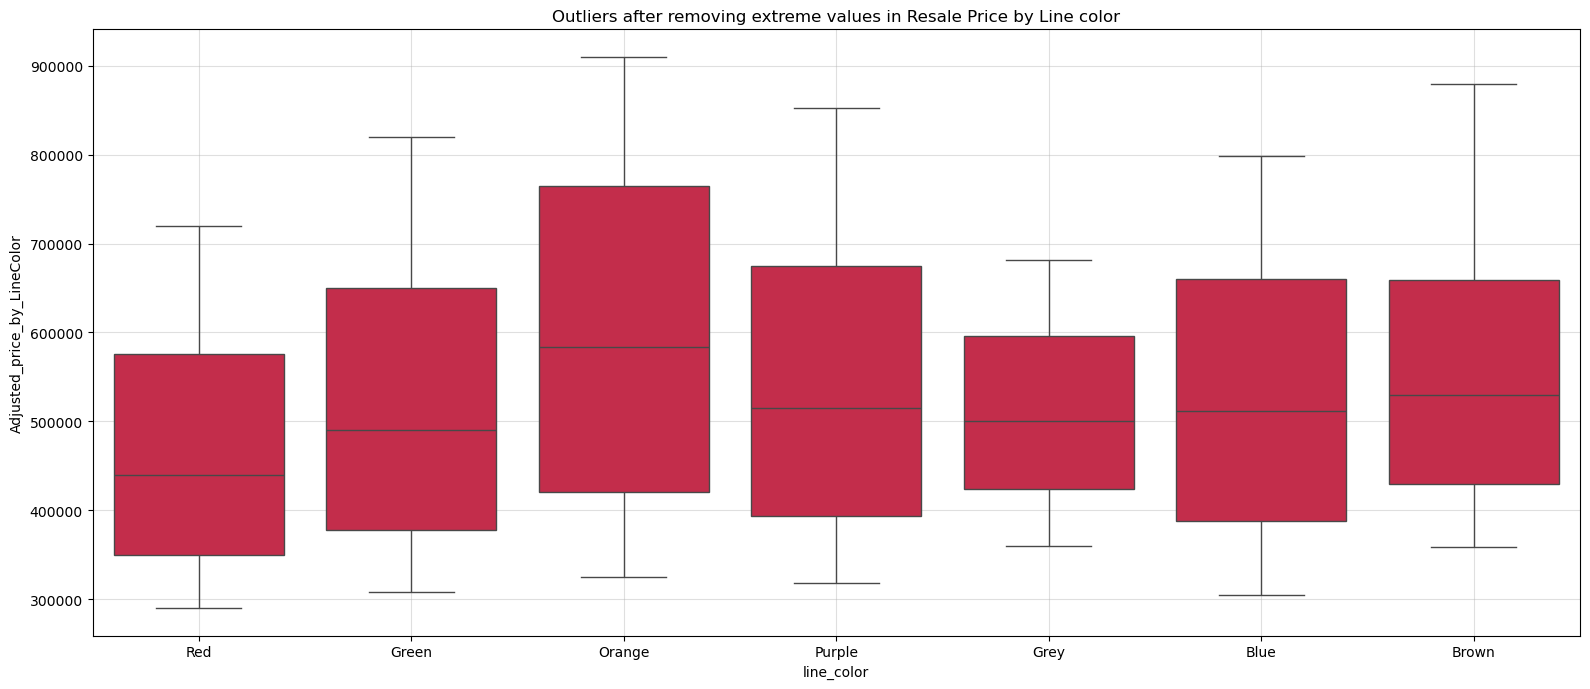

In [80]:
df['90_perc'] = df.groupby('line_color')['resale_price'].transform(lambda x: np.nanpercentile(x, 90))
df['10_perc'] = df.groupby('line_color')['resale_price'].transform(lambda x: np.nanpercentile(x, 10))

df['Adjusted_price_by_LineColor'] = df['resale_price']
df.loc[df['resale_price'] < df['10_perc'], 'Adjusted_price_by_LineColor'] = df['10_perc']
df.loc[df['resale_price'] > df['90_perc'], 'Adjusted_price_by_LineColor'] = df['90_perc']

plt.figure(figsize=(16, 7))
sns.boxplot(data=df, x='line_color', y='resale_price', color='crimson')
plt.title('Outliers in original Resale Price vs Line Color')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print()

plt.figure(figsize=(16, 7))
sns.boxplot(data=df, x='line_color', y='Adjusted_price_by_LineColor', color='crimson')
plt.title('Outliers after removing extreme values in Resale Price by Line color')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

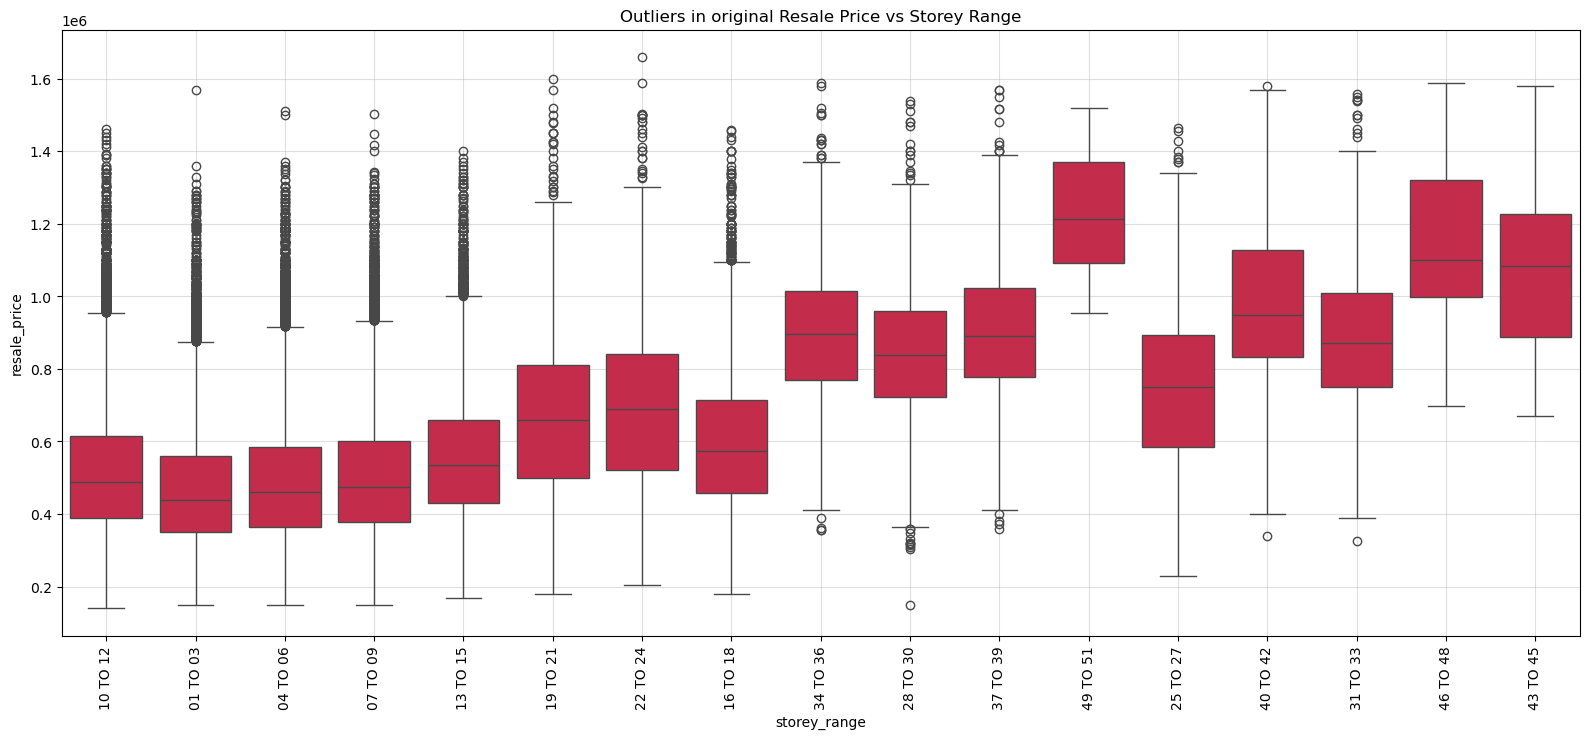

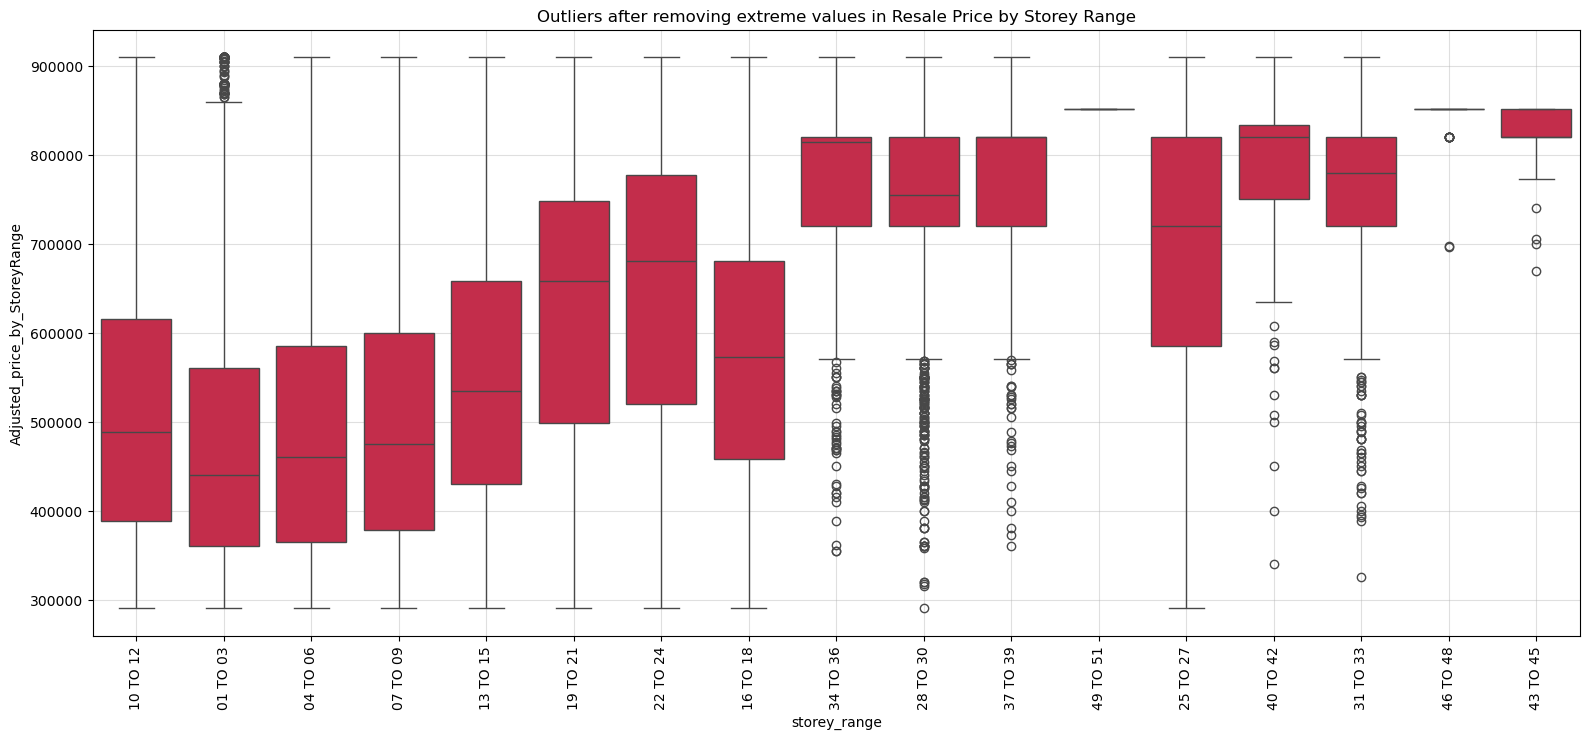

In [79]:
df['90_perc'] = df.groupby('line_color')['resale_price'].transform(lambda x: np.nanpercentile(x, 90))
df['10_perc'] = df.groupby('line_color')['resale_price'].transform(lambda x: np.nanpercentile(x, 10))

df['Adjusted_price_by_StoreyRange'] = df['resale_price']
df.loc[df['resale_price'] < df['10_perc'], 'Adjusted_price_by_StoreyRange'] = df['10_perc']
df.loc[df['resale_price'] > df['90_perc'], 'Adjusted_price_by_StoreyRange'] = df['90_perc']

plt.figure(figsize=(16, 7))
sns.boxplot(data=df, x='storey_range', y='resale_price', color='crimson')
plt.title('Outliers in original Resale Price vs Storey Range')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

print()

plt.figure(figsize=(16, 7))
sns.boxplot(data=df, x='storey_range', y='Adjusted_price_by_StoreyRange', color='crimson')
plt.title('Outliers after removing extreme values in Resale Price by Storey Range')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

Multiple versions of the resale price were created to handle outliers using different strategies and groupings. By keeping separate columns for each adjustment (e.g., by `flat_type` or `flat_model`), we can **compare the effects of different outlier treatments** without losing the original data. This approach provides **flexibility for analysis and modeling**, allowing us to test which preprocessing method leads to the **best predictive performance** while maintaining clear and reproducible workflows.

In [32]:
Q1 = df['resale_price'].quantile(0.25)
Q2 = df['resale_price'].quantile(0.75)
IQR = Q2 - Q1
print('Inter-Quartile Range: ', IQR)

Inter-Quartile Range:  239888.0


In [36]:
outliers = df['resale_price'][
        (df['resale_price'] < (Q1 - 1.5 * IQR)) | 
        (df['resale_price'] > (Q2 + 1.5 * IQR))
    ]

print('Outliers Shape: ', outliers.shape)

Outliers Shape:  (3858,)


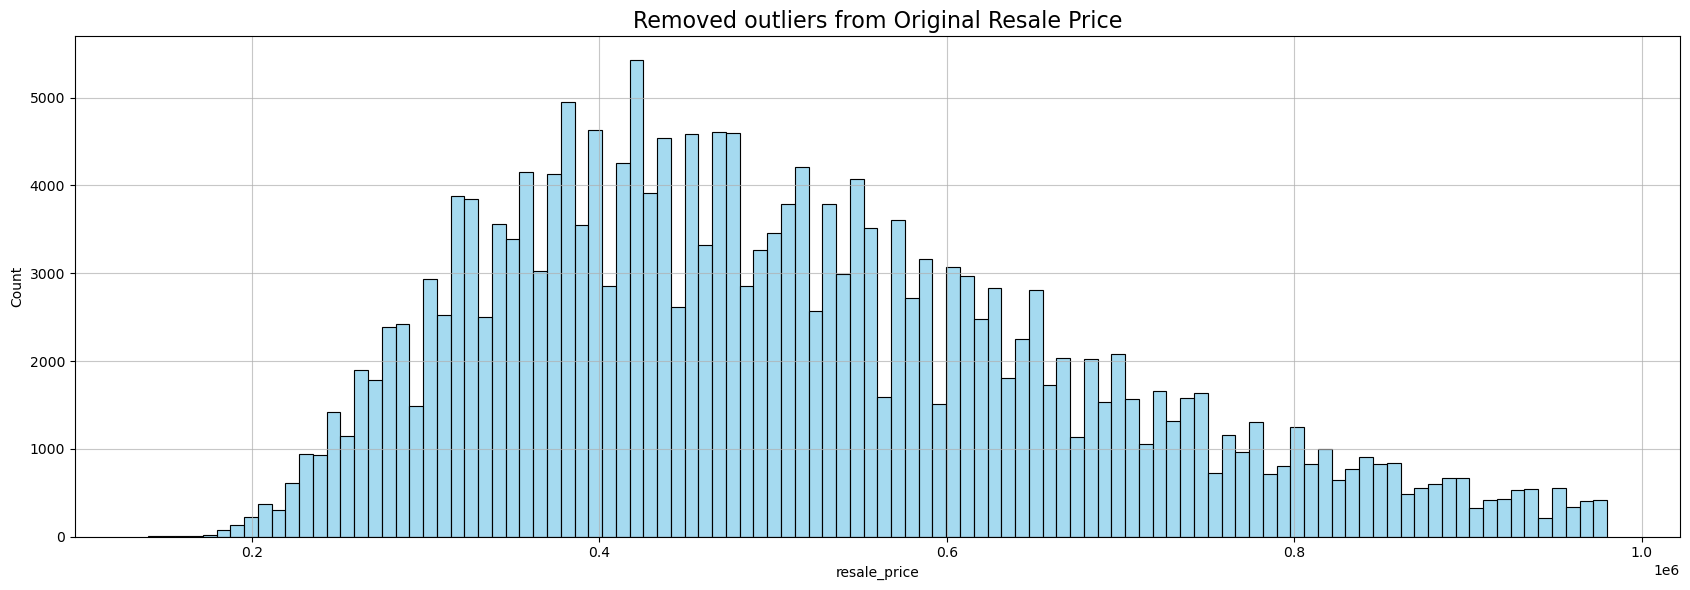

In [34]:
removed_outliers = df.drop(outliers.index)

plt.figure(figsize=(17, 6))
sns.histplot(data=removed_outliers, x='resale_price', color='skyblue')
plt.title('Removed outliers from Original Resale Price', fontsize=16)
plt.tight_layout()
plt.grid(True, alpha=0.7)
plt.show()

In [38]:
low_replace = df['resale_price'].quantile(0.05)
high_replace = df['resale_price'].quantile(0.95)
median_replace = df['resale_price'].quantile(0.5)

print(f'Low replace: {low_replace}, \nHigh replace: {high_replace}, \nMedian replace: {median_replace}')

Low replace: 277000.0, 
High replace: 868000.0, 
Median replace: 488000.0


In [61]:
df['Adjusted_price2'] = df['resale_price']
df.loc[df['resale_price'] < (Q1 - 1.5 * IQR), 'Adjusted_price2'] = low_replace
df.loc[df['resale_price'] > (Q2 - 1.5 * IQR), 'Adjusted_price2'] = high_replace

df['resale_price_with_nan'] = df['resale_price']
df.loc[outliers.index, 'resale_price_with_nan'] = np.nan

df.isnull().sum()

resale_price                        0
storey_range                        0
flat_type                           0
flat_model                          0
remaining_lease_months              0
floor_area_sqm                      0
planning_area_ura                   0
region_ura                          0
latitude                            0
longitude                           0
closest_mrt_station                 0
distance_to_mrt_meters              0
transport_type                      0
line_color                          0
distance_to_cbd                     0
closest_pri_school                  0
distance_to_pri_school_meters       0
total_lease_remaining_years         0
mahalanobis_distances               0
Adjusted_price                      0
90_perc                             0
10_perc                             0
Group_adjusted_price                0
Adjusted_price2                     0
resale_price_with_nan            3858
dtype: int64

In [62]:
df = df.interpolate(method='linear')
df['resale_price_with_nan'] = df['resale_price_with_nan'].astype(int)
df.loc[outliers.index, 'resale_price_with_nan'].head()

308     588000
660     829000
1319    840000
2477    906666
2478    878333
Name: resale_price_with_nan, dtype: int64

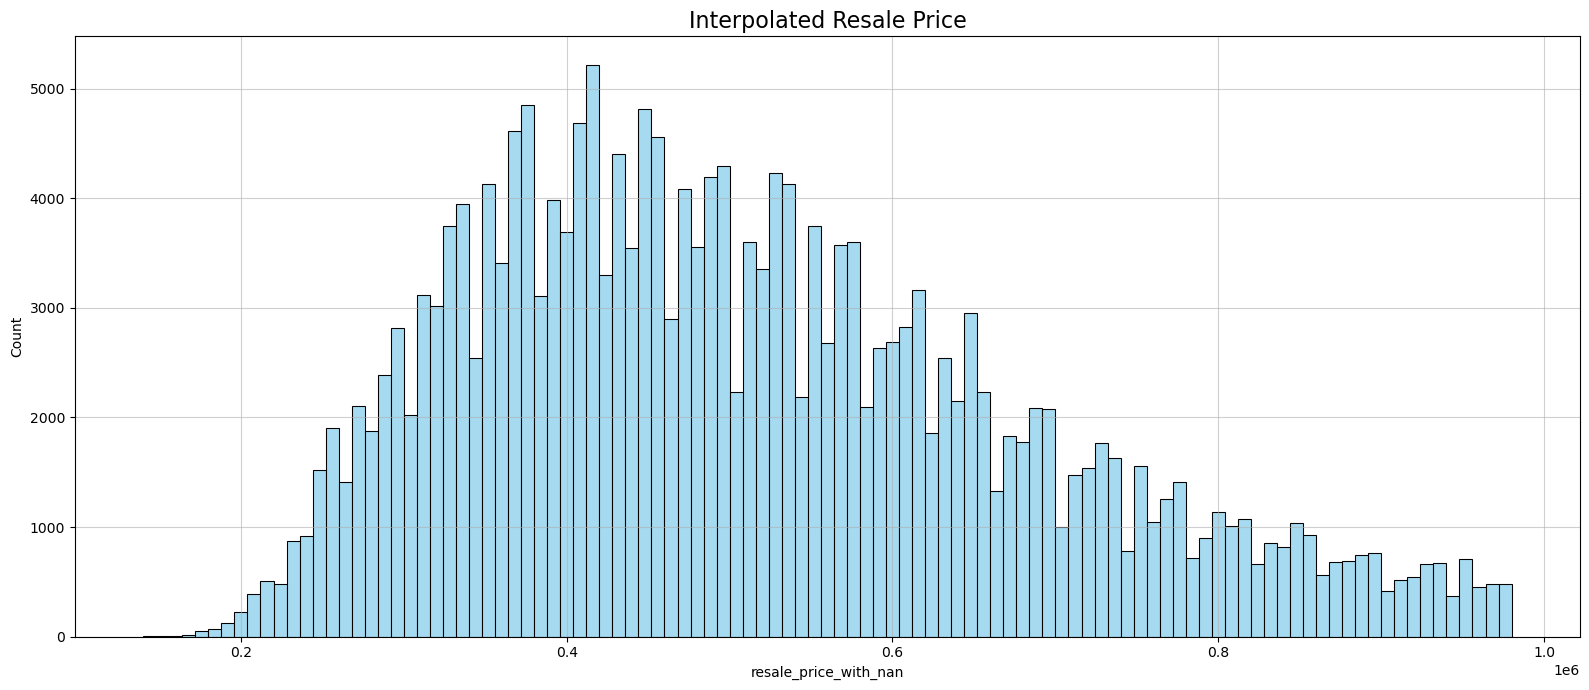

In [63]:
plt.figure(figsize=(16, 7))

ax = sns.histplot(data=df, x='resale_price_with_nan', color='skyblue')
plt.title('Interpolated Resale Price', fontsize=16)
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

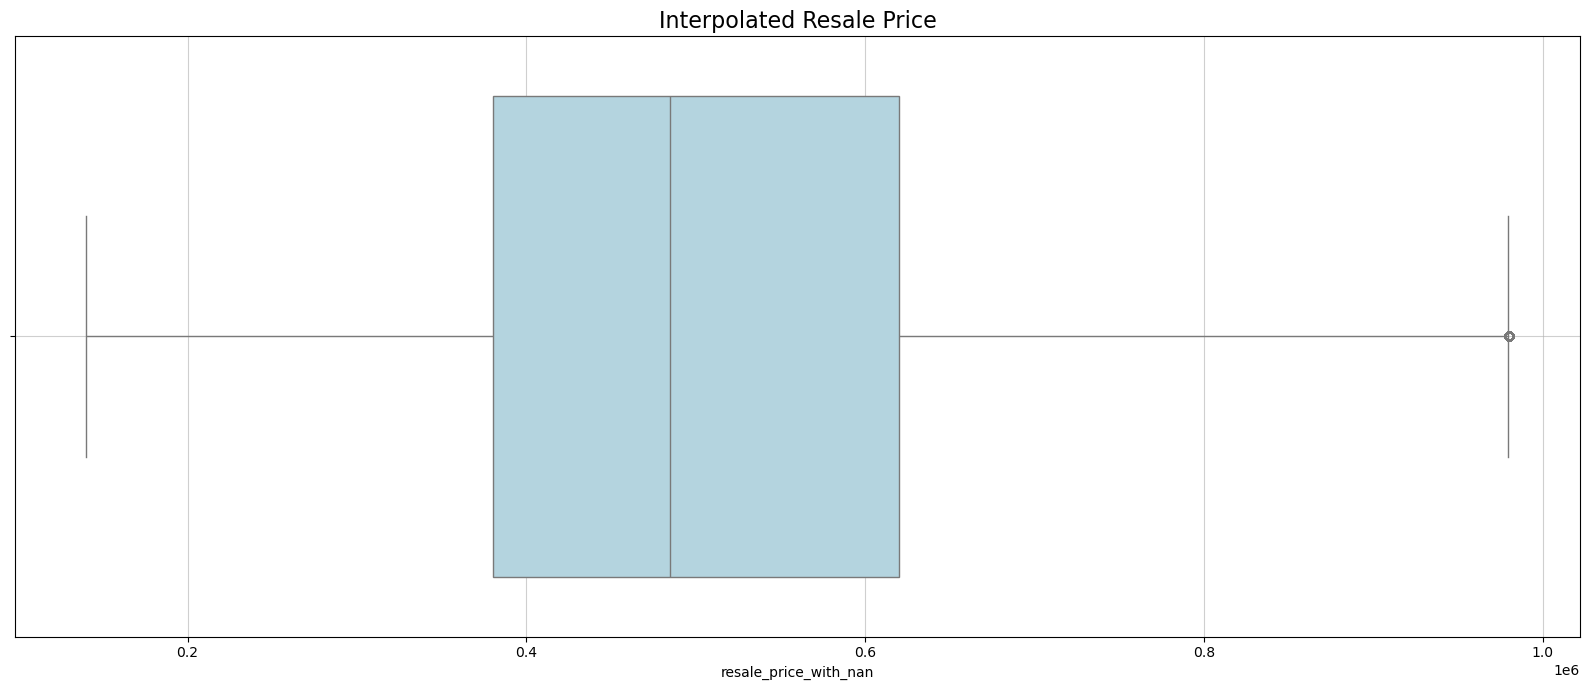

In [82]:
plt.figure(figsize=(16, 7))

ax = sns.boxplot(data=df, x='resale_price_with_nan', color='lightblue')
plt.title('Interpolated Resale Price', fontsize=16)
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

```
After experimenting with several outlier handling methods, including IQR-based removal and interpolation, the dataset is now cleaner and more consistent. The next step is to train and evaluate predictive models to identify which approach best captures the underlying patterns in resale prices. This will help determine the most robust model for accurate predictions across different flat types.